In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


DEADZONE GUARD DATASET
Original shape: (16066, 6)

Columns:
['temperature', 'humidity', 'mq2', 'mq135', 'Vibration', 'AQI_Level']

Cleaned shape: (16066, 6)

Class distribution:
AQI_Level
Unhealthy                         5158
Unhealthy for Sensitive Groups    3643
Good                              3640
Moderate                          3625
Name: count, dtype: int64

GAS SENSOR RANGE CHECK
MQ2 >= 1800:
AQI_Level
Unhealthy    2534
Name: count, dtype: int64

MQ135 >= 2000:
AQI_Level
Unhealthy    2573
Name: count, dtype: int64

CLASSES
0 -> Good
1 -> Moderate
2 -> Unhealthy
3 -> Unhealthy for Sensitive Groups

Training samples: 12852
Testing samples : 3214

Training: random_forest
Time: 624.97 seconds
Best CV F1: 0.9381
Best params:
{'clf__n_estimators': 500, 'clf__min_samples_split': 3, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 20}

Training: extra_trees
Time: 220.7 seconds
Best CV F1: 0.9401
Best params:
{'clf__n_estimators': 500, 'clf__min_samples_spli

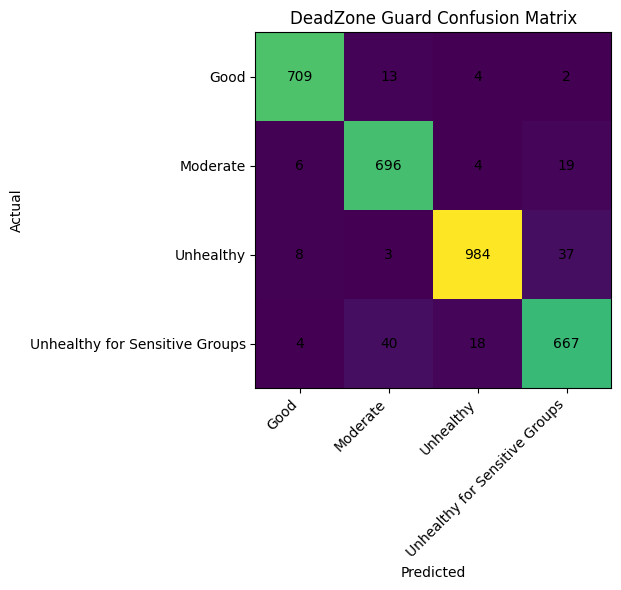


REAL SENSOR SAFETY TEST
Normal -> {'prediction': 'Good', 'reason': 'ML MODEL', 'confidence': 97.36}
MQ2 High -> {'prediction': 'Unhealthy', 'reason': 'MQ2 GAS LEVEL CRITICAL', 'confidence': 100.0}
MQ135 High -> {'prediction': 'Unhealthy', 'reason': 'MQ135 GAS LEVEL CRITICAL', 'confidence': 100.0}
Both Gas High -> {'prediction': 'Unhealthy', 'reason': 'MQ2 GAS LEVEL CRITICAL', 'confidence': 100.0}
Vibration -> {'prediction': 'DANGER', 'reason': 'VIBRATION DETECTED', 'confidence': 100.0}

MODEL SAVED
Model   : /content/DeadZoneGuard/deadzone_guard_model.pkl
Encoder : /content/DeadZoneGuard/label_encoder.pkl
Metrics : /content/DeadZoneGuard/metrics.json


In [ ]:
import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

CONFIG = {

    "data": {
        "path": "/content/drive/MyDrive/DeadZoneGuard2/deadzone_improved_dataset.csv",

        "features": [
            "temperature",
            "humidity",
            "mq2",
            "mq135"
        ],

        "target": "AQI_Level",

        "vibration_column": "Vibration"
    },

    "split": {
        "test_size": 0.20,
        "random_state": 42
    },

    "training": {
        "cv_folds": 5,
        "scoring": "f1_macro",
        "n_iter_search": 20,
        "random_state": 42
    },

    "artifacts": {
        "model_dir": "/content/DeadZoneGuard",

        "model_filename": "deadzone_guard_model.pkl",

        "encoder_filename": "label_encoder.pkl",

        "metrics_filename": "metrics.json"
    }
}


FEATURES = CONFIG["data"]["features"]
TARGET = CONFIG["data"]["target"]

GAS_MQ2_DANGER = 1800
GAS_MQ135_DANGER = 2000

VIBRATION_DANGER = "VIBRATING"


# ============================================================
# LOAD DATASET
# ============================================================

print("==============================================")
print("DEADZONE GUARD DATASET")
print("==============================================")

df = pd.read_csv(CONFIG["data"]["path"])

print("Original shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# CLEAN DATA
# ============================================================

for col in ["temperature", "humidity", "mq2", "mq135"]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=FEATURES + [
        TARGET,
        CONFIG["data"]["vibration_column"]
    ]
).copy()


df["mq2"] = df["mq2"].clip(0, 4095)

df["mq135"] = df["mq135"].clip(0, 4095)

df["temperature"] = df["temperature"].clip(20, 40)

df["humidity"] = df["humidity"].clip(0, 100)

df["Vibration"] = (
    df["Vibration"]
    .astype(str)
    .str.upper()
    .str.strip()
)


print("\nCleaned shape:", df.shape)

print("\nClass distribution:")
print(df[TARGET].value_counts())


# ============================================================
# CHECK EXTREME GAS DATA
# ============================================================

print("\n==============================================")
print("GAS SENSOR RANGE CHECK")
print("==============================================")

print(
    "MQ2 >= 1800:"
)

print(
    df[df["mq2"] >= GAS_MQ2_DANGER]
    [TARGET]
    .value_counts()
)

print(
    "\nMQ135 >= 2000:"
)

print(
    df[df["mq135"] >= GAS_MQ135_DANGER]
    [TARGET]
    .value_counts()
)


# ============================================================
# INPUT / OUTPUT
# ============================================================

X = df[FEATURES].astype(float)

y_text = df[TARGET].astype(str)


# ============================================================
# LABEL ENCODER
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y_text)


print("\n==============================================")
print("CLASSES")
print("==============================================")

for i, label in enumerate(label_encoder.classes_):

    print(
        f"{i} -> {label}"
    )


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=CONFIG["split"]["test_size"],

    random_state=CONFIG["split"]["random_state"],

    stratify=y
)


print("\nTraining samples:", len(X_train))

print("Testing samples :", len(X_test))


# ============================================================
# MODEL PIPELINE
# ============================================================

def build_pipeline(model):

    return Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "clf",
            model
        )
    ])


# ============================================================
# MODEL SEARCH
# ============================================================

models = {

    "random_forest": {

        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "params": {

            "clf__n_estimators": [
                300,
                500,
                700
            ],

            "clf__max_depth": [
                10,
                15,
                20,
                None
            ],

            "clf__min_samples_split": [
                2,
                3,
                5
            ],

            "clf__min_samples_leaf": [
                1,
                2
            ],

            "clf__max_features": [
                "sqrt",
                "log2"
            ]
        }
    },


    "extra_trees": {

        "model": ExtraTreesClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "params": {

            "clf__n_estimators": [
                300,
                500,
                700
            ],

            "clf__max_depth": [
                10,
                15,
                20,
                None
            ],

            "clf__min_samples_split": [
                2,
                3,
                5
            ],

            "clf__min_samples_leaf": [
                1,
                2
            ],

            "clf__max_features": [
                "sqrt",
                "log2"
            ]
        }
    },


    "hist_gradient_boosting": {

        "model": HistGradientBoostingClassifier(
            random_state=42
        ),

        "params": {

            "clf__max_iter": [
                200,
                300,
                400
            ],

            "clf__learning_rate": [
                0.03,
                0.05,
                0.1
            ],

            "clf__max_leaf_nodes": [
                15,
                31,
                63
            ],

            "clf__l2_regularization": [
                0,
                0.1,
                1
            ]
        }
    }
}


# ============================================================
# CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


search_results = {}


# ============================================================
# TRAIN MODELS
# ============================================================

for model_name, config in models.items():

    print("\n==============================================")

    print(
        "Training:",
        model_name
    )

    print("==============================================")


    pipeline = build_pipeline(
        config["model"]
    )


    search = RandomizedSearchCV(

        estimator=pipeline,

        param_distributions=config["params"],

        n_iter=20,

        scoring="f1_macro",

        cv=cv,

        random_state=42,

        n_jobs=-1,

        refit=True
    )


    start = time.time()


    search.fit(
        X_train,
        y_train
    )


    elapsed = time.time() - start


    print(
        "Time:",
        round(elapsed, 2),
        "seconds"
    )


    print(
        "Best CV F1:",
        round(
            search.best_score_,
            4
        )
    )


    print(
        "Best params:"
    )

    print(
        search.best_params_
    )


    search_results[
        model_name
    ] = search


# ============================================================
# SELECT BEST MODEL
# ============================================================

best_key = max(

    search_results,

    key=lambda x:
    search_results[x].best_score_

)


best_search = search_results[
    best_key
]


best_model = best_search.best_estimator_


print("\n==============================================")

print(
    "BEST MODEL:",
    best_key
)

print(
    "CV F1:",
    round(
        best_search.best_score_,
        4
    )
)

print("==============================================")


# ============================================================
# TRAINING PERFORMANCE
# ============================================================

train_pred = best_model.predict(
    X_train
)

test_pred = best_model.predict(
    X_test
)


train_accuracy = accuracy_score(
    y_train,
    train_pred
)


test_accuracy = accuracy_score(
    y_test,
    test_pred
)


test_f1 = f1_score(
    y_test,
    test_pred,
    average="macro"
)


print("\n==============================================")
print("MODEL PERFORMANCE")
print("==============================================")


print(
    f"Training Accuracy : {train_accuracy * 100:.2f}%"
)


print(
    f"Test Accuracy     : {test_accuracy * 100:.2f}%"
)


print(
    f"Test F1 Macro     : {test_f1:.4f}"
)


print("\nClassification Report:")


print(
    classification_report(

        y_test,

        test_pred,

        target_names=
        label_encoder.classes_,

        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_pred
)


plt.figure(
    figsize=(8, 6)
)

plt.imshow(cm)

plt.title(
    "DeadZone Guard Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()


# ============================================================
# SAFETY-AWARE PREDICTION
# ============================================================

def predict_sensor(
    temperature,
    humidity,
    mq2,
    mq135,
    vibration
):

    temperature = float(temperature)

    humidity = float(humidity)

    mq2 = float(mq2)

    mq135 = float(mq135)

    vibration = str(
        vibration
    ).upper().strip()


    # --------------------------------------------------------
    # 1. VIBRATION SAFETY OVERRIDE
    # --------------------------------------------------------

    if vibration == VIBRATION_DANGER:

        return {

            "prediction":
            "DANGER",

            "reason":
            "VIBRATION DETECTED",

            "confidence":
            100.0
        }


    # --------------------------------------------------------
    # 2. MQ2 SAFETY OVERRIDE
    # --------------------------------------------------------

    if mq2 >= GAS_MQ2_DANGER:

        return {

            "prediction":
            "Unhealthy",

            "reason":
            "MQ2 GAS LEVEL CRITICAL",

            "confidence":
            100.0
        }


    # --------------------------------------------------------
    # 3. MQ135 SAFETY OVERRIDE
    # --------------------------------------------------------

    if mq135 >= GAS_MQ135_DANGER:

        return {

            "prediction":
            "Unhealthy",

            "reason":
            "MQ135 GAS LEVEL CRITICAL",

            "confidence":
            100.0
        }


    # --------------------------------------------------------
    # 4. ML MODEL
    # --------------------------------------------------------

    sensor_data = np.array([

        [
            temperature,
            humidity,
            mq2,
            mq135
        ]

    ])


    pred_encoded = best_model.predict(
        sensor_data
    )[0]


    probabilities = (
        best_model
        .predict_proba(sensor_data)[0]
    )


    predicted_label = (
        label_encoder
        .inverse_transform(
            [pred_encoded]
        )[0]
    )


    confidence = (
        np.max(probabilities) * 100
    )


    return {

        "prediction":
        str(predicted_label),

        "reason":
        "ML MODEL",

        "confidence":
        round(
            float(confidence),
            2
        )
    }


# ============================================================
# REAL SENSOR TESTS
# ============================================================

print("\n==============================================")
print("REAL SENSOR SAFETY TEST")
print("==============================================")


tests = [

    {
        "name":
        "Normal",

        "temperature":
        29.8,

        "humidity":
        99.0,

        "mq2":
        150,

        "mq135":
        120,

        "vibration":
        "STABLE"
    },


    {
        "name":
        "MQ2 High",

        "temperature":
        29.8,

        "humidity":
        99.0,

        "mq2":
        4095,

        "mq135":
        100,

        "vibration":
        "STABLE"
    },


    {
        "name":
        "MQ135 High",

        "temperature":
        29.8,

        "humidity":
        99.0,

        "mq2":
        100,

        "mq135":
        4095,

        "vibration":
        "STABLE"
    },


    {
        "name":
        "Both Gas High",

        "temperature":
        29.8,

        "humidity":
        99.0,

        "mq2":
        4095,

        "mq135":
        4095,

        "vibration":
        "STABLE"
    },


    {
        "name":
        "Vibration",

        "temperature":
        29.8,

        "humidity":
        99.0,

        "mq2":
        150,

        "mq135":
        120,

        "vibration":
        "VIBRATING"
    }

]


for test in tests:

    result = predict_sensor(

        test["temperature"],

        test["humidity"],

        test["mq2"],

        test["mq135"],

        test["vibration"]

    )


    print(
        test["name"],
        "->",
        result
    )


# ============================================================
# SAVE MODEL
# ============================================================

model_dir = Path(
    CONFIG["artifacts"]["model_dir"]
)

model_dir.mkdir(
    parents=True,
    exist_ok=True
)


model_path = (
    model_dir /
    CONFIG["artifacts"]["model_filename"]
)


encoder_path = (
    model_dir /
    CONFIG["artifacts"]["encoder_filename"]
)


metrics_path = (
    model_dir /
    CONFIG["artifacts"]["metrics_filename"]
)


joblib.dump(
    best_model,
    model_path
)


joblib.dump(
    label_encoder,
    encoder_path
)


metrics = {

    "selected_model":
    best_key,

    "classes":
    label_encoder.classes_.tolist(),

    "features":
    FEATURES,

    "cv_f1_macro":
    round(
        float(best_search.best_score_),
        4
    ),

    "train_accuracy":
    round(
        float(train_accuracy),
        4
    ),

    "test_accuracy":
    round(
        float(test_accuracy),
        4
    ),

    "test_f1_macro":
    round(
        float(test_f1),
        4
    ),

    "mq2_danger_threshold":
    GAS_MQ2_DANGER,

    "mq135_danger_threshold":
    GAS_MQ135_DANGER,

    "all_candidates_cv_scores": {

        k:
        round(
            float(v.best_score_),
            4
        )

        for k, v
        in search_results.items()
    }
}


with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )


print("\n==============================================")
print("MODEL SAVED")
print("==============================================")


print(
    "Model   :",
    model_path
)


print(
    "Encoder :",
    encoder_path
)


print(
    "Metrics :",
    metrics_path
)

In [ ]:
from google.colab import files

files.download(str(model_path))
files.download(str(encoder_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>